<a href="https://colab.research.google.com/github/kandalpreeti-ctrl/RecycleVision--Garbage-Image-Classification-Using-Deep-Learning/blob/main/ds_recyclevision_garbage_image_classification_using.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import data from kaggle

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mostafaabla/garbage-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'garbage-classification' dataset.
Path to dataset files: /kaggle/input/garbage-classification


In [ ]:
import os
os.listdir(path)

['garbage_classification']

In [ ]:
import os
os.listdir(os.path.join(path, 'garbage_classification'))

['metal',
 'white-glass',
 'biological',
 'paper',
 'brown-glass',
 'battery',
 'trash',
 'cardboard',
 'shoes',
 'clothes',
 'plastic',
 'green-glass']

In [ ]:
import kagglehub
import os

# 1. Download the dataset
path = kagglehub.dataset_download("mostafaabla/garbage-classification")
print("Dataset path:", path)

# 2. Create a list of all image files
image_files = []
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(('.jpg', '.jpeg', '.png')):
            image_files.append(os.path.join(root, file))

print(f"Total {len(image_files)} images found.")


Using Colab cache for faster access to the 'garbage-classification' dataset.
Dataset path: /kaggle/input/garbage-classification
Total 15515 images found.


display /kaggle/input/garbage-classification/garbage_classification/metal/metal375.jpg


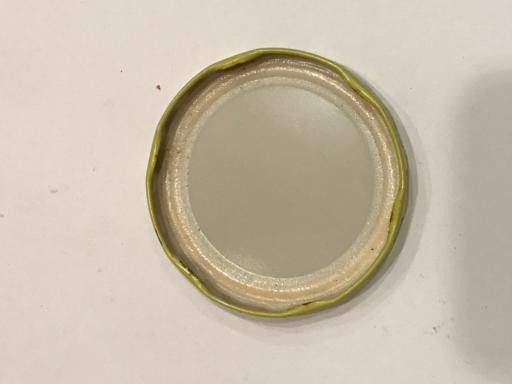

display /kaggle/input/garbage-classification/garbage_classification/metal/metal561.jpg


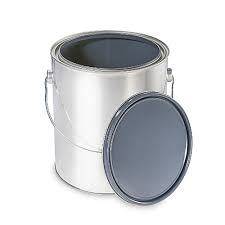

display /kaggle/input/garbage-classification/garbage_classification/metal/metal341.jpg


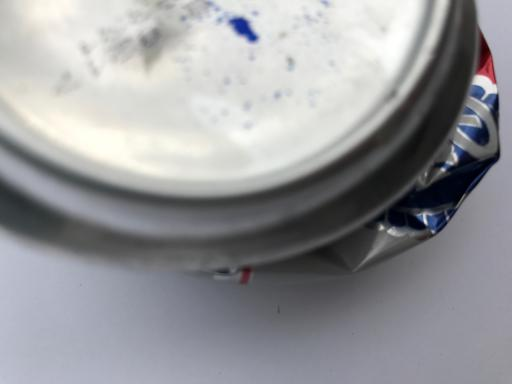

display /kaggle/input/garbage-classification/garbage_classification/metal/metal688.jpg


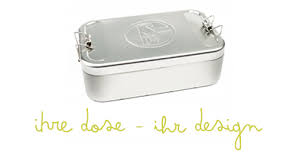

display /kaggle/input/garbage-classification/garbage_classification/metal/metal374.jpg


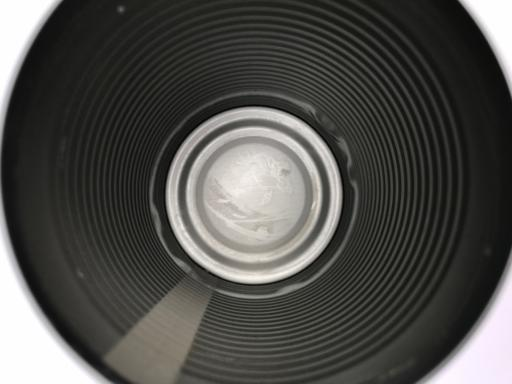

In [ ]:
from IPython.display import Image, display

# first 5 image display
for img_path in image_files[:5]:
    print(f"display {img_path}")
    display(Image(filename=img_path, width=200))


Cleaning & Preprocessing

In [ ]:
import tensorflow as tf
import os
import kagglehub

# Download latest version to ensure 'path' is defined
path = kagglehub.dataset_download("mostafaabla/garbage-classification")

# Data path (modify according to your folder structure)
data_dir = os.path.join(path, "garbage_classification")

# 1. Training Dataset (80% of data)
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224), # Resizing images is necessary
    batch_size=16          # Batch size reduced to 16 to save memory
)

# 2. Validation Dataset (20% of data)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=16          # Batch size reduced to 16 to save memory
)

Using Colab cache for faster access to the 'garbage-classification' dataset.
Found 15515 files belonging to 12 classes.
Using 12412 files for training.
Found 15515 files belonging to 12 classes.
Using 3103 files for validation.


In [ ]:
import tensorflow as tf

# 1. Normalization (Scaling pixel values from 0-255 to 0-1)
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# 2. Data Augmentation (Flipping and zooming images to help the model learn better)
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.1),
])

# Apply Augmentation only to the Training data
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# 3. Prefetching (Memory management to speed up training)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Step 2 (Preprocessing & Augmentation) completed!")

Step 2 (Preprocessing & Augmentation) completed!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os


Visualize Class Distribution)

Example Images

Using Colab cache for faster access to the 'garbage-classification' dataset.


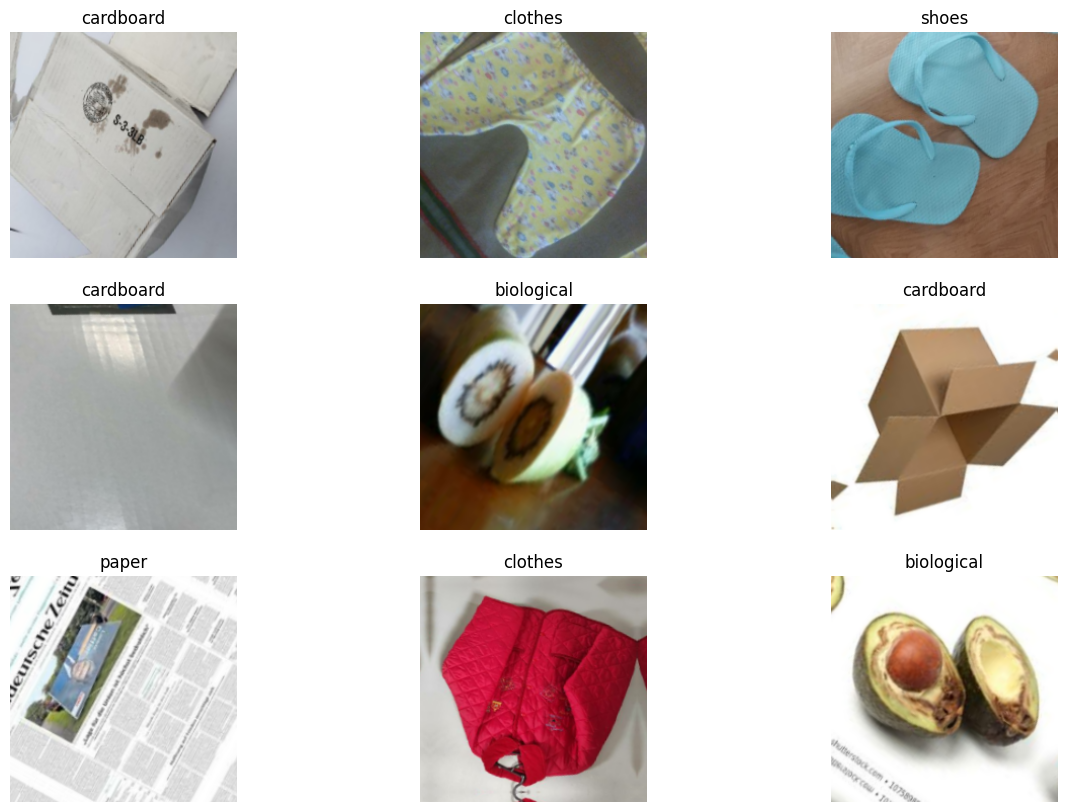

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import kagglehub

# Ensure 'path' and 'data_dir' are defined for this cell's execution
path = kagglehub.dataset_download("mostafaabla/garbage-classification")
data_dir = os.path.join(path, "garbage_classification")

# Get class names
class_names = sorted(os.listdir(data_dir)) # Get class names directly from the directory

plt.figure(figsize=(15, 10))
# Take a few images from the first batch
for images, labels in train_ds.take(1):
    for i in range(9): # Show the first 9 images
        ax = plt.subplot(3, 3, i + 1)

        # Convert normalized image back to 0-255 for display if it's float and between 0-1
        if images[i].numpy().max() <= 1.0:
            display_image = (images[i].numpy() * 255).astype('uint8')
        else:
            display_image = images[i].numpy().astype('uint8')

        plt.imshow(display_image)

        # For one-hot encoded labels, use np.argmax. For integer labels, use labels[i].
        # Assuming labels are integer encoded here for simplicity, but checking shape is safer.
        label_index = np.argmax(labels[i]) if len(labels.shape) > 1 else int(labels[i])

        plt.title(class_names[label_index])
        plt.axis("off")
plt.show()

Model Development (Transfer Learning)


all Metrics and Confusion Matrix for code

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Agar model pehle se nahi banaya toh aise banega:
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(12) # Kyunki aapke paas 12 classes hain
])

# Model ko compile aur train karna zaroori hai evaluation se pehle
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Agar model train ho chuka hai, tabhi predictions kaam karengi
# model.fit(train_ds, validation_data=val_ds, epochs=5)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import os
import kagglehub
# Ensure 'path' and 'data_dir' are defined for class_names
path = kagglehub.dataset_download("mostafaabla/garbage-classification")
data_dir = os.path.join(path, "garbage_classification")
class_names = sorted(os.listdir(data_dir))



# 1. Dataset Load


IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
#
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
#   Normalization TRAIN MODEL
train_ds = train_ds.map(lambda x, y: (x/255.0, y))
val_ds = val_ds.map(lambda x, y: (x/255.0, y))

# Re-compile the model to ensure the optimizer is fresh and correctly linked
# to the current model variables.
# Using the same optimizer and loss as defined in cell 86ee7e72
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TRAIN MODEL

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)
# SAVE MODEL
model.save("garbage_classifier.keras")

Found 15515 files belonging to 12 classes.
Using 12412 files for training.
Found 15515 files belonging to 12 classes.
Using 3103 files for validation.
Epoch 1/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 48s 96ms/step - accuracy: 0.9845 - loss: 0.0465 - val_accuracy: 0.9297 - val_loss: 0.2890
Epoch 2/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.9858 - loss: 0.0404 - val_accuracy: 0.9333 - val_loss: 0.2775
Epoch 3/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.9898 - loss: 0.0307 - val_accuracy: 0.9375 - val_loss: 0.2674
Epoch 4/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.9901 - loss: 0.0273 - val_accuracy: 0.9362 - val_loss: 0.3081
Epoch 5/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.9902 - loss: 0.0300 - val_accuracy: 0.9352 - val_loss: 0.2828
Epoch 6/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 41s 62ms/step - accuracy: 0.9925 - loss: 0.0229 - val_accuracy: 0.9323 - val_loss: 0.3116
Epoch 7/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 24s 63ms/step - accuracy: 0.9

Evaluating the model, please wait...

--- Classification Report ---
              precision    recall  f1-score   support

     battery       0.07      0.91      0.14       187
  biological       0.03      0.01      0.01       200
 brown-glass       0.10      0.02      0.04       133
   cardboard       0.00      0.00      0.00       178
     clothes       0.34      0.01      0.03      1070
 green-glass       0.07      0.08      0.07       115
       metal       0.00      0.00      0.00       168
       paper       0.00      0.00      0.00       198
     plastic       0.05      0.03      0.04       184
       shoes       0.00      0.00      0.00       391
       trash       0.00      0.00      0.00       136
 white-glass       0.03      0.10      0.05       143

    accuracy                           0.07      3103
   macro avg       0.06      0.10      0.03      3103
weighted avg       0.14      0.07      0.03      3103



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


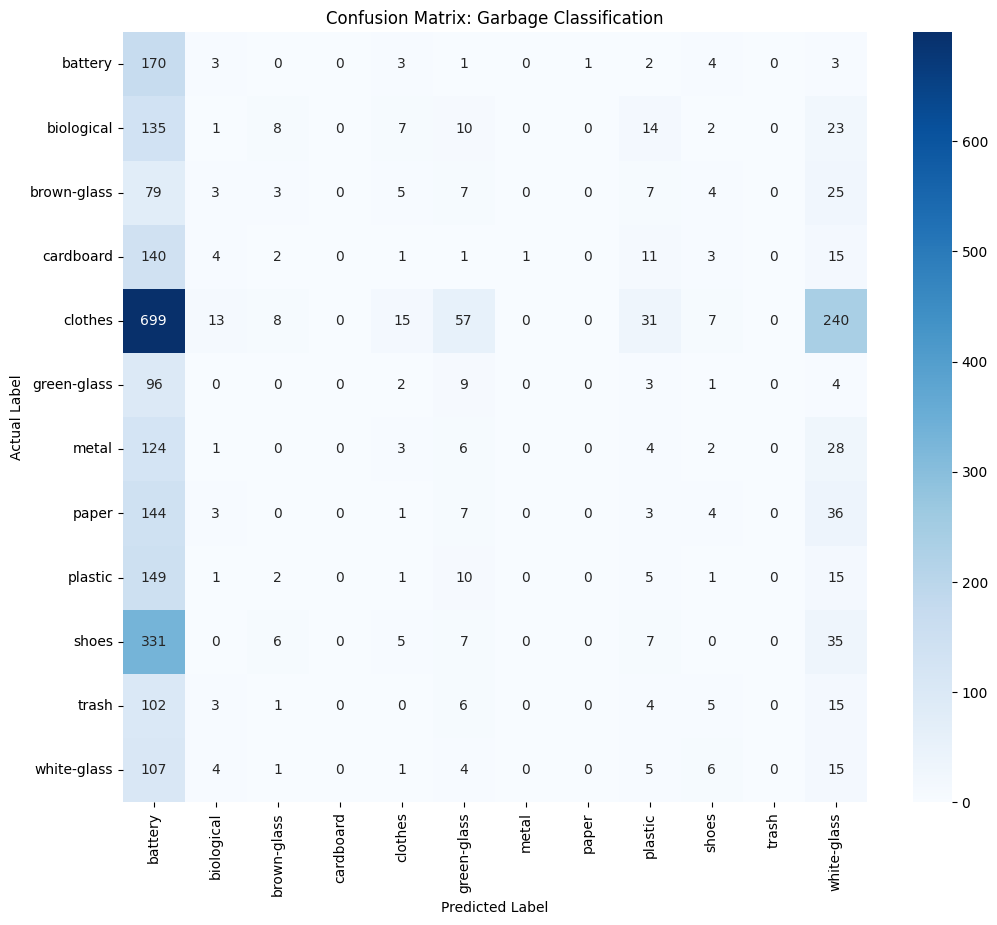

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Get true labels and predictions from the Validation data
y_true = []
y_pred = []

print("Evaluating the model, please wait...")

# Loop through the dataset to extract predictions
for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# 2. Print Classification Report (Precision, Recall, F1-Score)
# Use the global class_names as val_ds.class_names might not be available after prefetching
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# 3. Visualize the Confusion Matrix
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Confusion Matrix: Garbage Classification')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [ ]:
import tensorflow as tf
import os
import kagglehub

# Download latest version to ensure 'path' is defined
path = kagglehub.dataset_download("mostafaabla/garbage-classification")

# Data path (modify according to your folder structure)
data_dir = os.path.join(path, "garbage_classification")

# 1. Training Dataset (80% of data)
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224), # Resizing images is necessary
    batch_size=16          # Batch size reduced to 16 to save memory
)

# 2. Validation Dataset (20% of data)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=16          # Batch size reduced to 16 to save memory
)

Using Colab cache for faster access to the 'garbage-classification' dataset.
Found 15515 files belonging to 12 classes.
Using 12412 files for training.
Found 15515 files belonging to 12 classes.
Using 3103 files for validation.


In [ ]:
import tensorflow as tf

# 1. Normalization (Scaling pixel values from 0-255 to 0-1)
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# 2. Data Augmentation (Flipping and zooming images to help the model learn better)
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.1),
])

# Apply Augmentation only to the Training data
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# 3. Prefetching (Memory management to speed up training)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Step 2 (Preprocessing & Augmentation) completed!")

Step 2 (Preprocessing & Augmentation) completed!


Visualize Misclassifications

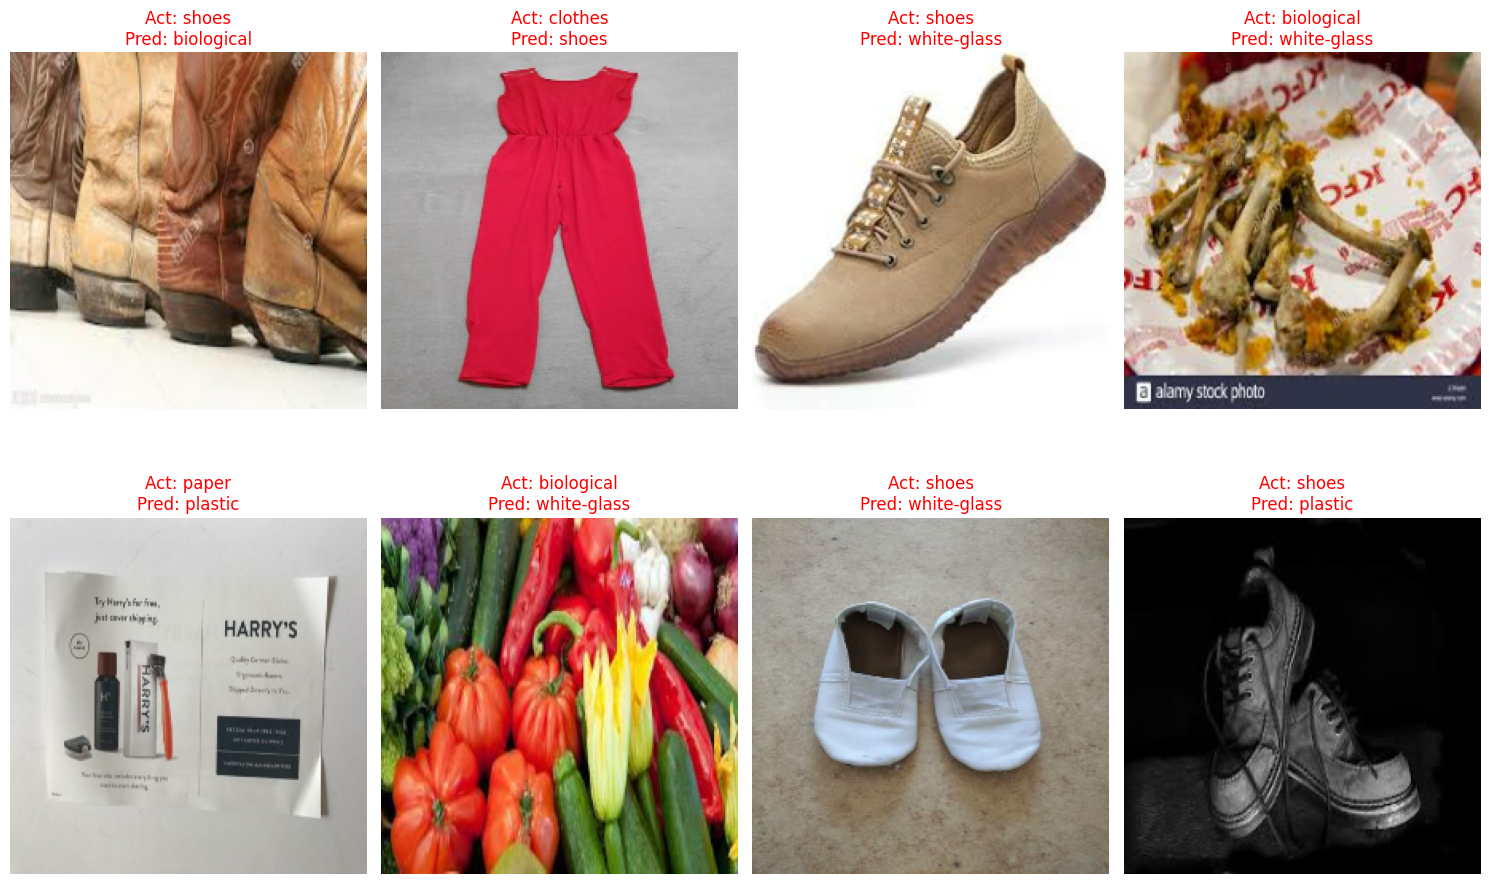

In [ ]:
# Visualize some incorrect predictions
plt.figure(figsize=(15, 10))
count = 0

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    for i in range(len(labels)):
        # Check if prediction is wrong and we haven't displayed 8 images yet
        if pred_labels[i] != labels[i] and count < 8:
            plt.subplot(2, 4, count + 1)

            # Bring pixel values back to the correct range (if Normalization was applied)
            display_img = images[i].numpy().astype("uint8") if images[i].numpy().max() > 1 else images[i].numpy()

            plt.imshow(display_img)
            plt.title(f"Act: {class_names[labels[i]]}\nPred: {class_names[pred_labels[i]]}", color='red')
            plt.axis('off')
            count += 1

    if count >= 8:
        break

plt.tight_layout()
plt.show()


In [ ]:
import tensorflow as tf

# Load the previously saved model
model = tf.keras.models.load_model('garbage_classifier.keras')

# Now save it with the new name
model.save('garbage_classifier_2026.keras')
print("Model Saved as 'garbage_classifier_2026.keras'")

Model Saved as 'garbage_classifier_2026.keras'


In [ ]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 56.3 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import os

st.title("♻️ Garbage Image Classifier")

# Load model
model = tf.keras.models.load_model("garbage_classifier_2026.h5")

# Class names (updated to match the 12 classes the model was trained on)
classes = [
    "battery",
    "biological",
    "brown-glass",
    "cardboard",
    "clothes",
    "green-glass",
    "metal",
    "paper",
    "plastic",
    "shoes",
    "trash",
    "white-glass"
]

# File Uploader
uploaded_file = st.file_uploader(
    "Upload Garbage Image",
    type=["jpg", "png", "jpeg"],
    key="garbage_uploader"
)

if uploaded_file is not None:
    # Display the uploaded image
    img = Image.open(uploaded_file)
    st.image(img, caption="Uploaded Image", width=300)

    # Generate a unique filename to save
    file_extension = uploaded_file.name.split('.')[-1]
    file_name = f"uploaded_garbage_{os.urandom(4).hex()}.{file_extension}"
    save_path = os.path.join(UPLOAD_FOLDER, file_name)

    # Save the PIL Image object to the file system
    try:
        img.save(save_path)
        st.success(f"Image saved to: {save_path}")
    except Exception as e:
        st.error(f"Error saving image: {e}")

    # Preprocess image for model prediction
    img_resized = img.resize((224, 224))
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Make prediction
    prediction = model.predict(img_array)[0]

    # Get top 3 predictions
    top3 = prediction.argsort()[-3:][::-1]

    st.subheader("Prediction Results")
    for i in top3:
        st.write(f"{classes[i]} : {prediction[i]*100:.2f}%")


Overwriting app.py


In [ ]:
!pip install streamlit pyngrok tensorflow pillow

In [ ]:
!ls

app.py				garbage_classifier.keras  uploaded_images
garbage_classifier_2026.h5	nohup.out
garbage_classifier_2026_new.h5	sample_data


In [ ]:
!kill $(lsof -t -i:8501) > /dev/null 2>&1
!nohup streamlit run app.py &

nohup: appending output to 'nohup.out'


In [ ]:
from pyngrok import ngrok

# Disconnect any existing ngrok tunnels
ngrok.kill()

# IMPORTANT: Replace "YOUR_NGROK_AUTH_TOKEN" with your actual ngrok authentication token
# Get your token from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token("3BCyQLKGSMWRqN6KwISXLMWuJny_6eKLY3gv4AuPYbQc4QUzh")
url = ngrok.connect(8501)
print(url)

NgrokTunnel: "https://sartorially-homophonic-gretta.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
from pyngrok import ngrok

# old tunnels band karo
ngrok.kill()

# direct connect
public_url = ngrok.connect(8501, bind_tls=True)
print(public_url)

NgrokTunnel: "https://sartorially-homophonic-gretta.ngrok-free.dev" -> "http://localhost:8501"
